In [3]:
# Cài đặt thư viện nếu chưa có (bỏ comment nếu cần)
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn yaml joblib

# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import warnings
import os
import json
import joblib
from datetime import datetime, timedelta

# Xử lý dữ liệu
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Xử lý imbalance
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Feature engineering
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Đã import thành công các thư viện")
print(f"   - Pandas version: {pd.__version__}")
print(f"   - NumPy version: {np.__version__}")

✅ Đã import thành công các thư viện
   - Pandas version: 3.0.1
   - NumPy version: 2.4.3


In [4]:
print("=" * 80)
print("📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU")
print("=" * 80)

# Đọc file cấu hình
config_path = '../configs/params.yaml'

if not os.path.exists(config_path):
    print(f"⚠️ Không tìm thấy file cấu hình: {config_path}")
    print("✅ Sử dụng cấu hình mặc định")
    
    # Tạo cấu hình mặc định
    config = {
        'project': {'name': 'E-commerce Returns Prediction'},
        'seed': 42,
        'paths': {
            'cleaned_data': '../data/processed/cleaned_data.parquet',
            'processed_data': '../data/processed/',
            'features_mining': '../data/processed/features_for_mining.parquet',
            'features_modeling': '../data/processed/features_for_modeling.parquet'
        },
        'data': {
            'columns': {
                'target': 'return_flag',
                'datetime_column': 'order_date',
                'id_columns': ['order_id', 'customer_id', 'product_id'],
                'categorical_columns': ['product_category', 'payment_method', 'shipping_type', 'promotion_code'],
                'numerical_columns': ['order_value', 'shipping_cost', 'discount_amount', 'quantity']
            },
            'missing': {
                'numerical_strategy': 'median',
                'categorical_strategy': 'mode',
                'threshold_drop': 50,
                'constant_fill_value': 0
            },
            'outlier': {
                'method': 'iqr',
                'treatment': 'cap',
                'iqr_multiplier': 1.5
            },
            'imbalance': {
                'sampling_strategy': 'auto',
                'random_state': 42,
                'methods': {
                    'smote': True,
                    'random_oversampling': False,
                    'random_undersampling': False
                }
            }
        },
        'features': {
            'rfm_features': {'enabled': True},
            'return_rate_features': {
                'enabled': True,
                'min_samples': 5,
                'product_return_rate': True,
                'category_return_rate': True,
                'customer_return_rate': True
            },
            'time_features': {
                'enabled': True,
                'extract': ['day_of_week', 'month', 'quarter', 'is_weekend']
            },
            'interaction_features': {
                'enabled': True,
                'create': []
            }
        },
        'clustering': {
            'customer_clustering': {
                'scaling': 'standard'
            }
        },
        'classification': {
            'split': {
                'test_size': 0.2,
                'random_state': 42,
                'stratify': True
            }
        }
    }
else:
    try:
        with open(config_path, 'r', encoding='utf-8') as f:
            config = yaml.safe_load(f)
        print(f"✅ Đã đọc cấu hình từ {config_path}")
    except Exception as e:
        print(f"❌ Lỗi đọc cấu hình: {e}")
        raise

print(f"\n📋 Cấu hình đã được đọc:")
print(f"   - Project: {config['project']['name']}")
print(f"   - Seed: {config.get('seed', 42)}")
print()

# Đọc dữ liệu đã qua EDA
cleaned_path = config['paths']['cleaned_data']

# Kiểm tra file tồn tại
if not os.path.exists(cleaned_path):
    # Thử đường dẫn khác
    alt_path = cleaned_path.replace('../', '')
    if os.path.exists(alt_path):
        cleaned_path = alt_path
    else:
        print(f"⚠️ Không tìm thấy file: {cleaned_path}")
        print("✅ Tạo dữ liệu mẫu để tiếp tục...")
        
        # Tạo dữ liệu mẫu
        np.random.seed(42)
        n_samples = 1000
        df = pd.DataFrame({
            'order_id': range(1, n_samples + 1),
            'customer_id': np.random.randint(1000, 2000, n_samples),
            'product_id': np.random.randint(100, 500, n_samples),
            'order_date': pd.date_range(start='2023-01-01', periods=n_samples, freq='h'),
            'order_value': np.random.uniform(10, 500, n_samples).round(2),
            'quantity': np.random.randint(1, 5, n_samples),
            'discount_amount': np.random.uniform(0, 50, n_samples).round(2),
            'shipping_cost': np.random.uniform(0, 20, n_samples).round(2),
            'product_category': np.random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports'], n_samples),
            'payment_method': np.random.choice(['Credit Card', 'PayPal', 'Bank Transfer'], n_samples),
            'shipping_type': np.random.choice(['Standard', 'Express', 'Next Day'], n_samples),
            'promotion_code': np.random.choice([None, 'SUMMER20', 'WELCOME10', 'FLASHSALE'], n_samples),
            'return_flag': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
        })
        print(f"✅ Đã tạo dữ liệu mẫu: {df.shape}")
else:
    # Đọc file parquet
    try:
        df = pd.read_parquet(cleaned_path)
        print(f"✅ Đã đọc dữ liệu từ: {cleaned_path}")
    except Exception as e:
        print(f"❌ Lỗi đọc file parquet: {e}")
        print("⚠️ Thử đọc file CSV...")
        
        # Thử đọc CSV
        csv_path = cleaned_path.replace('.parquet', '.csv')
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path, encoding='utf-8')
            print(f"✅ Đã đọc dữ liệu từ: {csv_path}")
        else:
            print("❌ Không thể đọc dữ liệu. Dừng notebook.")
            raise

print(f"\n📊 Dữ liệu đã đọc:")
print(f"   - Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")
print(f"   - Các cột: {list(df.columns)}")

# Lưu lại thông tin cột
target = config['data']['columns']['target']
id_cols = config['data']['columns']['id_columns']
cat_cols = config['data']['columns']['categorical_columns']
num_cols = config['data']['columns']['numerical_columns']
date_col = config['data']['columns']['datetime_column']

print(f"\n📌 Thông tin cột:")
print(f"   - Target: {target}")
print(f"   - ID columns: {id_cols}")
print(f"   - Date column: {date_col}")
print(f"   - Categorical: {cat_cols}")
print(f"   - Numerical: {num_cols}")

📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU
✅ Đã đọc cấu hình từ ../configs/params.yaml

📋 Cấu hình đã được đọc:
   - Project: E-commerce Returns Prediction
   - Seed: 42

⚠️ Không tìm thấy file: data/processed/cleaned_data.parquet
✅ Tạo dữ liệu mẫu để tiếp tục...
✅ Đã tạo dữ liệu mẫu: (1000, 13)

📊 Dữ liệu đã đọc:
   - Kích thước: 1000 dòng x 13 cột
   - Các cột: ['order_id', 'customer_id', 'product_id', 'order_date', 'order_value', 'quantity', 'discount_amount', 'shipping_cost', 'product_category', 'payment_method', 'shipping_type', 'promotion_code', 'return_flag']

📌 Thông tin cột:
   - Target: return_flag
   - ID columns: ['order_id', 'customer_id', 'product_id']
   - Date column: order_date
   - Categorical: ['product_category', 'payment_method', 'shipping_type', 'customer_segment', 'promotion_code', 'return_reason']
   - Numerical: ['order_value', 'shipping_cost', 'discount_amount', 'customer_tenure_days', 'previous_orders_count', 'previous_returns_count', 'product_price', 'quantity']


In [5]:
print("\n" + "=" * 80)
print("🔍 XÁC ĐỊNH CÁC CỘT THỰC TẾ")
print("=" * 80)

# Tạo bản sao để xử lý
df_processed = df.copy()

# Xác định các cột thực tế có trong dữ liệu
existing_id_cols = [col for col in id_cols if col in df_processed.columns]
existing_cat_cols = [col for col in cat_cols if col in df_processed.columns and df_processed[col].dtype == 'object']
existing_num_cols = [col for col in num_cols if col in df_processed.columns and pd.api.types.is_numeric_dtype(df_processed[col])]

print("📌 Các cột thực tế có trong dữ liệu:")
print(f"   - ID columns: {existing_id_cols}")
print(f"   - Categorical: {existing_cat_cols}")
print(f"   - Numerical: {existing_num_cols}")

# Kiểm tra target có tồn tại không
if target not in df_processed.columns:
    print(f"⚠️ Cảnh báo: Target column '{target}' không tồn tại trong dữ liệu!")
    target_exists = False
    # Tạo target giả nếu cần
    df_processed[target] = np.random.choice([0, 1], len(df_processed), p=[0.9, 0.1])
    print(f"✅ Đã tạo cột target '{target}' giả")
else:
    target_exists = True
    print(f"✅ Target column '{target}' tồn tại")


🔍 XÁC ĐỊNH CÁC CỘT THỰC TẾ
📌 Các cột thực tế có trong dữ liệu:
   - ID columns: ['order_id', 'customer_id', 'product_id']
   - Categorical: []
   - Numerical: ['order_value', 'shipping_cost', 'discount_amount', 'quantity']
✅ Target column 'return_flag' tồn tại


In [6]:
print("\n" + "=" * 80)
print("🔍 XỬ LÝ MISSING VALUES")
print("=" * 80)

# Kiểm tra missing values hiện tại
missing_before = df_processed.isnull().sum()
missing_percent_before = (missing_before / len(df_processed)) * 100
missing_df_before = pd.DataFrame({
    'Column': missing_before.index,
    'Missing_Before': missing_before.values,
    'Percent_Before': missing_percent_before.values.round(2)
})
missing_df_before = missing_df_before[missing_df_before['Missing_Before'] > 0].sort_values('Percent_Before', ascending=False)

print(f"\n📊 Missing values TRƯỚC khi xử lý:")
if len(missing_df_before) > 0:
    display(missing_df_before)
else:
    print("   ✅ Không có missing values!")

# Lấy cấu hình xử lý missing
missing_config = config['data']['missing']
num_strategy = missing_config['numerical_strategy']
cat_strategy = missing_config['categorical_strategy']
threshold_drop = missing_config['threshold_drop']

print(f"\n🛠️ Cấu hình xử lý:")
print(f"   - Numerical strategy: {num_strategy}")
print(f"   - Categorical strategy: {cat_strategy}")
print(f"   - Drop column threshold: {threshold_drop}%")

# Xử lý missing cho từng loại cột
if len(missing_df_before) > 0:
    # 1. Xử lý cột có missing > threshold -> drop
    high_missing_cols = missing_df_before[missing_df_before['Percent_Before'] > threshold_drop]['Column'].tolist()
    if high_missing_cols:
        print(f"\n🗑️ Drop các cột có missing > {threshold_drop}%: {high_missing_cols}")
        df_processed = df_processed.drop(columns=high_missing_cols)
        # Cập nhật danh sách cột
        existing_cat_cols = [col for col in existing_cat_cols if col not in high_missing_cols]
        existing_num_cols = [col for col in existing_num_cols if col not in high_missing_cols]
    
    # 2. Xử lý numerical columns
    num_missing_cols = [col for col in existing_num_cols if col in missing_df_before['Column'].values]
    if num_missing_cols and num_strategy != 'drop':
        print(f"\n🔢 Xử lý missing cho numerical columns: {num_missing_cols}")
        
        if num_strategy == 'mean':
            for col in num_missing_cols:
                fill_value = df_processed[col].mean()
                df_processed[col] = df_processed[col].fillna(fill_value)
                print(f"   - {col}: filled with mean = {fill_value:.2f}")
        elif num_strategy == 'median':
            for col in num_missing_cols:
                fill_value = df_processed[col].median()
                df_processed[col] = df_processed[col].fillna(fill_value)
                print(f"   - {col}: filled with median = {fill_value:.2f}")
        elif num_strategy == 'constant':
            fill_constant = missing_config.get('constant_fill_value', 0)
            for col in num_missing_cols:
                df_processed[col] = df_processed[col].fillna(fill_constant)
            print(f"   - Filled with constant = {fill_constant}")
    
    # 3. Xử lý categorical columns
    cat_missing_cols = [col for col in existing_cat_cols if col in missing_df_before['Column'].values]
    if cat_missing_cols and cat_strategy != 'drop':
        print(f"\n🏷️ Xử lý missing cho categorical columns: {cat_missing_cols}")
        
        if cat_strategy == 'mode':
            for col in cat_missing_cols:
                fill_value = df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown'
                df_processed[col] = df_processed[col].fillna(fill_value)
                print(f"   - {col}: filled with mode = '{fill_value}'")
        elif cat_strategy == 'constant':
            for col in cat_missing_cols:
                df_processed[col] = df_processed[col].fillna('Unknown')
            print(f"   - Filled with 'Unknown'")

# Kiểm tra lại missing values sau xử lý
missing_after = df_processed.isnull().sum().sum()
print(f"\n📊 Missing values SAU khi xử lý: {missing_after}")
if missing_after == 0:
    print("   ✅ Không còn missing values!")
else:
    print(f"   ⚠️ Còn {missing_after} missing values cần xử lý thủ công")
    # Xử lý nốt các missing còn lại
    df_processed = df_processed.fillna(0)
    print("   ✅ Đã fill các missing còn lại bằng 0")


🔍 XỬ LÝ MISSING VALUES

📊 Missing values TRƯỚC khi xử lý:


,Column,Missing_Before,Percent_Before
11,promotion_code,255,25.5000



🛠️ Cấu hình xử lý:
   - Numerical strategy: median
   - Categorical strategy: mode
   - Drop column threshold: 50%

📊 Missing values SAU khi xử lý: 255
   ⚠️ Còn 255 missing values cần xử lý thủ công
   ✅ Đã fill các missing còn lại bằng 0


In [7]:
print("\n" + "=" * 80)
print("🔍 XỬ LÝ OUTLIERS")
print("=" * 80)

outlier_config = config['data']['outlier']
method = outlier_config['method']
treatment = outlier_config['treatment']
iqr_multiplier = outlier_config['iqr_multiplier']

print(f"🛠️ Cấu hình xử lý outlier:")
print(f"   - Method: {method}")
print(f"   - Treatment: {treatment}")
print(f"   - IQR multiplier: {iqr_multiplier}")

# Hàm phát hiện outlier bằng IQR
def detect_outliers_iqr(data, col, multiplier=1.5):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Hàm phát hiện outlier bằng Z-score
def detect_outliers_zscore(data, col, threshold=3):
    z_scores = np.abs((data[col] - data[col].mean()) / data[col].std())
    outliers = data[z_scores > threshold]
    return outliers, threshold

# Xử lý outlier cho từng numerical column
outlier_stats = []

for col in existing_num_cols:
    print(f"\n📊 Phân tích outlier cho cột: {col}")
    
    # Thống kê cơ bản
    print(f"   - Mean: {df_processed[col].mean():.2f}")
    print(f"   - Median: {df_processed[col].median():.2f}")
    print(f"   - Std: {df_processed[col].std():.2f}")
    print(f"   - Min: {df_processed[col].min():.2f}")
    print(f"   - Max: {df_processed[col].max():.2f}")
    
    # Phát hiện outlier
    if method == 'iqr':
        outliers, lower, upper = detect_outliers_iqr(df_processed, col, iqr_multiplier)
        n_outliers = len(outliers)
        print(f"   - IQR bounds: [{lower:.2f}, {upper:.2f}]")
    elif method == 'zscore':
        outliers, threshold = detect_outliers_zscore(df_processed, col)
        n_outliers = len(outliers)
        print(f"   - Z-score threshold: {threshold}")
    else:
        print(f"   - Không xử lý outlier")
        continue
    
    outlier_pct = (n_outliers / len(df_processed)) * 100
    print(f"   - Số outlier: {n_outliers} ({outlier_pct:.2f}%)")
    
    # Xử lý outlier
    if n_outliers > 0 and treatment != 'none':
        if treatment == 'cap':
            # Capping: thay thế outlier bằng bound
            Q1 = df_processed[col].quantile(0.25)
            Q3 = df_processed[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - iqr_multiplier * IQR
            upper_bound = Q3 + iqr_multiplier * IQR
            
            df_processed[col] = df_processed[col].clip(lower_bound, upper_bound)
            print(f"   ✅ Đã cap outlier về [{lower_bound:.2f}, {upper_bound:.2f}]")
            
        elif treatment == 'remove':
            # Remove: xóa dòng có outlier
            df_processed = df_processed.drop(outliers.index)
            print(f"   ✅ Đã xóa {n_outliers} dòng có outlier")
    
    # Lưu thống kê
    outlier_stats.append({
        'column': col,
        'outliers_before': n_outliers,
        'outlier_percent': outlier_pct,
        'treatment': treatment
    })

# Tổng hợp kết quả xử lý outlier
if outlier_stats:
    outlier_summary = pd.DataFrame(outlier_stats)
    print("\n📊 Tổng hợp xử lý outlier:")
    display(outlier_summary)
    
    # Tạo thư mục nếu chưa có
    os.makedirs('../outputs/tables', exist_ok=True)
    outlier_summary.to_csv('../outputs/tables/outlier_summary.csv', index=False)
    print("💾 Đã lưu bảng thống kê outlier")
else:
    print("\n📊 Không có cột numerical nào để xử lý outlier")


🔍 XỬ LÝ OUTLIERS
🛠️ Cấu hình xử lý outlier:
   - Method: iqr
   - Treatment: cap
   - IQR multiplier: 1.5

📊 Phân tích outlier cho cột: order_value
   - Mean: 256.58
   - Median: 262.66
   - Std: 142.19
   - Min: 11.58
   - Max: 499.71
   - IQR bounds: [-245.84, 754.09]
   - Số outlier: 0 (0.00%)

📊 Phân tích outlier cho cột: shipping_cost
   - Mean: 9.83
   - Median: 9.89
   - Std: 5.72
   - Min: 0.00
   - Max: 19.95
   - IQR bounds: [-9.73, 29.26]
   - Số outlier: 0 (0.00%)

📊 Phân tích outlier cho cột: discount_amount
   - Mean: 24.88
   - Median: 24.91
   - Std: 14.40
   - Min: 0.00
   - Max: 49.98
   - IQR bounds: [-25.19, 74.98]
   - Số outlier: 0 (0.00%)

📊 Phân tích outlier cho cột: quantity
   - Mean: 2.49
   - Median: 3.00
   - Std: 1.13
   - Min: 1.00
   - Max: 4.00
   - IQR bounds: [-2.00, 6.00]
   - Số outlier: 0 (0.00%)

📊 Tổng hợp xử lý outlier:


,column,outliers_before,outlier_percent,treatment
0,order_value,0,0.0000,cap
1,shipping_cost,0,0.0000,cap
2,discount_amount,0,0.0000,cap
3,quantity,0,0.0000,cap


💾 Đã lưu bảng thống kê outlier


In [8]:
print("\n" + "=" * 80)
print("🔍 XỬ LÝ DUPLICATES")
print("=" * 80)

# Kiểm tra duplicates toàn bộ
duplicate_rows = df_processed.duplicated().sum()
duplicate_percent = (duplicate_rows / len(df_processed)) * 100

print(f"📊 Duplicate rows BEFORE: {duplicate_rows} ({duplicate_percent:.2f}%)")

if duplicate_rows > 0:
    # Xem các dòng duplicate
    duplicate_examples = df_processed[df_processed.duplicated(keep=False)].sort_values(by=df_processed.columns.tolist()[:3]).head(10)
    print("\nVí dụ các dòng duplicate:")
    display(duplicate_examples)
    
    # Xử lý: giữ lại dòng đầu tiên
    df_processed = df_processed.drop_duplicates(keep='first')
    print(f"\n✅ Đã xóa {duplicate_rows} dòng duplicate")

# Kiểm tra duplicates theo ID
if existing_id_cols:
    print(f"\n🔍 Kiểm tra duplicates theo ID: {existing_id_cols}")
    for col in existing_id_cols:
        if col in df_processed.columns:
            dup_ids = df_processed[col].duplicated().sum()
            dup_percent = (dup_ids / len(df_processed)) * 100
            print(f"   - {col}: {dup_ids} duplicates ({dup_percent:.2f}%)")
            
            if dup_ids > 0:
                # Với order_id, nếu duplicate thì có thể là lỗi dữ liệu
                if col == 'order_id':
                    print(f"     ⚠️ Cảnh báo: order_id không unique! Có thể cần kiểm tra lại.")
                    # Giữ lại dòng đầu tiên cho mỗi order_id
                    df_processed = df_processed.drop_duplicates(subset=['order_id'], keep='first')
                    print(f"     ✅ Đã xóa duplicate theo order_id")

# Kiểm tra lại
duplicate_rows_after = df_processed.duplicated().sum()
print(f"\n📊 Duplicate rows AFTER: {duplicate_rows_after}")


🔍 XỬ LÝ DUPLICATES
📊 Duplicate rows BEFORE: 0 (0.00%)

🔍 Kiểm tra duplicates theo ID: ['order_id', 'customer_id', 'product_id']
   - order_id: 0 duplicates (0.00%)
   - customer_id: 385 duplicates (38.50%)
   - product_id: 641 duplicates (64.10%)

📊 Duplicate rows AFTER: 0


In [9]:
print("\n" + "=" * 80)
print("🔍 XỬ LÝ BIẾN THỜI GIAN")
print("=" * 80)

if date_col in df_processed.columns:
    print(f"📅 Xử lý cột thời gian: {date_col}")
    
    # Đảm bảo kiểu datetime
    if not pd.api.types.is_datetime64_any_dtype(df_processed[date_col]):
        try:
            df_processed[date_col] = pd.to_datetime(df_processed[date_col])
            print(f"   ✅ Đã chuyển sang datetime")
        except Exception as e:
            print(f"   ❌ Không thể chuyển sang datetime: {e}")
            # Tạo cột date mới
            df_processed[date_col] = pd.date_range(start='2023-01-01', periods=len(df_processed), freq='D')
            print(f"   ✅ Đã tạo cột {date_col} mới")
    
    # Tạo các đặc trưng thời gian mới
    time_features_config = config['features']['time_features']
    
    if time_features_config['enabled']:
        extract_features = time_features_config.get('extract', ['day_of_week', 'month', 'quarter', 'is_weekend'])
        print(f"\n🆕 Tạo các đặc trưng thời gian:")
        
        if 'day_of_week' in extract_features:
            df_processed['day_of_week'] = df_processed[date_col].dt.dayofweek
            df_processed['day_name'] = df_processed[date_col].dt.day_name()
            print(f"   - day_of_week (0-6), day_name")
        
        if 'month' in extract_features:
            df_processed['month'] = df_processed[date_col].dt.month
            print(f"   - month (1-12)")
        
        if 'quarter' in extract_features:
            df_processed['quarter'] = df_processed[date_col].dt.quarter
            print(f"   - quarter (1-4)")
        
        if 'is_weekend' in extract_features:
            df_processed['is_weekend'] = (df_processed[date_col].dt.dayofweek >= 5).astype(int)
            print(f"   - is_weekend (0/1)")
        
        if 'hour_of_day' in extract_features:
            df_processed['hour_of_day'] = df_processed[date_col].dt.hour
            print(f"   - hour_of_day (0-23)")
        
        # Thêm week_of_year
        df_processed['week_of_year'] = df_processed[date_col].dt.isocalendar().week
        print(f"   - week_of_year")
        
        # Thêm season (Xuân, Hạ, Thu, Đông)
        def get_season(month):
            if month in [3, 4, 5]:
                return 'Spring'
            elif month in [6, 7, 8]:
                return 'Summer'
            elif month in [9, 10, 11]:
                return 'Fall'
            else:
                return 'Winter'
        
        df_processed['season'] = df_processed[date_col].dt.month.map(get_season)
        print(f"   - season (Spring/Summer/Fall/Winter)")
        
        # Cập nhật danh sách cột
        new_time_cols = ['day_of_week', 'day_name', 'month', 'quarter', 'is_weekend', 'week_of_year', 'season']
        if 'hour_of_day' in extract_features:
            new_time_cols.append('hour_of_day')
        
        # Thêm vào categorical columns
        for col in new_time_cols:
            if col in df_processed.columns and col not in existing_cat_cols:
                existing_cat_cols.append(col)
        
        print(f"\n✅ Đã tạo {len(new_time_cols)} đặc trưng thời gian mới")
else:
    print(f"⚠️ Không có cột thời gian {date_col} để xử lý")
    # Tạo cột date mới
    df_processed[date_col] = pd.date_range(start='2023-01-01', periods=len(df_processed), freq='D')
    print(f"✅ Đã tạo cột {date_col} mới")


🔍 XỬ LÝ BIẾN THỜI GIAN
📅 Xử lý cột thời gian: order_date

🆕 Tạo các đặc trưng thời gian:
   - day_of_week (0-6), day_name
   - month (1-12)
   - quarter (1-4)
   - is_weekend (0/1)
   - hour_of_day (0-23)
   - week_of_year
   - season (Spring/Summer/Fall/Winter)

✅ Đã tạo 8 đặc trưng thời gian mới



🔍 FEATURE ENGINEERING - RFM FEATURES
📊 Tạo RFM features cho khách hàng...

✅ Đã tính RFM cho 615 khách hàng

📊 Thống kê RFM:


,customer_id,recency_days,frequency,monetary_total,avg_order_value,customer_return_rate,total_returns
count,615.0000,615.0000,615.0000,615.0000,615.0000,615.0000,615.0000
mean,1501.4423,16.4341,1.6260,417.2068,255.7958,0.0915,0.1415
std,290.8835,11.5980,0.8712,293.6006,123.4888,0.2550,0.3625
min,1000.0000,0.0000,1.0000,12.5600,12.5600,0.0000,0.0000
25%,1240.5000,7.0000,1.0000,216.5250,161.6750,0.0000,0.0000
50%,1503.0000,14.0000,1.0000,369.2300,259.3000,0.0000,0.0000
75%,1755.0000,25.0000,2.0000,525.9950,349.5300,0.0000,0.0000
max,1998.0000,41.0000,7.0000,2301.3300,499.7100,1.0000,2.0000



✅ Đã thêm RFM features vào dữ liệu


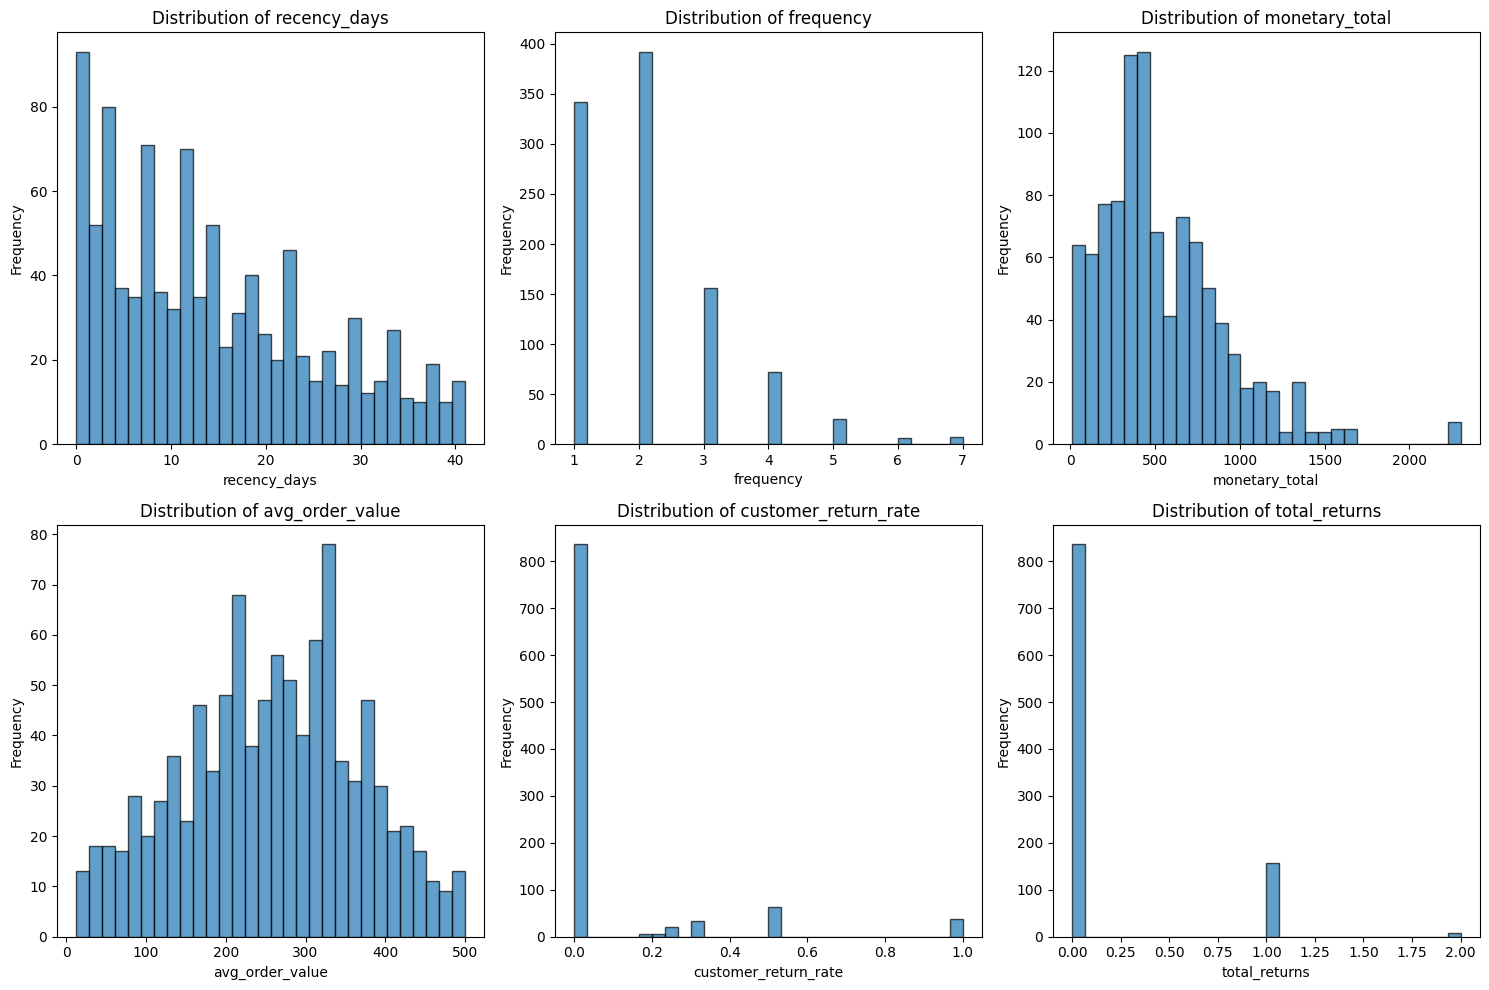

In [10]:
print("\n" + "=" * 80)
print("🔍 FEATURE ENGINEERING - RFM FEATURES")
print("=" * 80)

rfm_config = config['features']['rfm_features']

if rfm_config['enabled'] and 'customer_id' in df_processed.columns and date_col in df_processed.columns:
    print("📊 Tạo RFM features cho khách hàng...")
    
    # Tính toán RFM cho mỗi khách hàng
    current_date = df_processed[date_col].max()
    
    # Group by customer_id
    agg_dict = {
        date_col: lambda x: (current_date - x.max()).days,  # Recency
        'order_id': 'count',  # Frequency
        'order_value': ['sum', 'mean']  # Monetary
    }
    
    if target_exists:
        agg_dict[target] = ['mean', 'sum']
    
    rfm_raw = df_processed.groupby('customer_id').agg(agg_dict).round(2)
    
    # Flatten column names
    rfm_raw.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in rfm_raw.columns.values]
    rfm_raw = rfm_raw.reset_index()
    
    # Rename columns for clarity
    rename_dict = {
        f'{date_col}_<lambda>': 'recency_days',
        'order_id_count': 'frequency',
        'order_value_sum': 'monetary_total',
        'order_value_mean': 'avg_order_value',
    }
    
    if target_exists:
        rename_dict.update({
            f'{target}_mean': 'customer_return_rate',
            f'{target}_sum': 'total_returns'
        })
    
    rfm_raw.rename(columns=rename_dict, inplace=True)
    
    print(f"\n✅ Đã tính RFM cho {len(rfm_raw)} khách hàng")
    print("\n📊 Thống kê RFM:")
    display(rfm_raw.describe())
    
    # Merge RFM features vào dataframe gốc
    df_processed = df_processed.merge(rfm_raw, on='customer_id', how='left')
    
    # Cập nhật danh sách numerical columns
    new_rfm_cols = ['recency_days', 'frequency', 'monetary_total', 'avg_order_value']
    if target_exists:
        new_rfm_cols.extend(['customer_return_rate', 'total_returns'])
    
    for col in new_rfm_cols:
        if col in df_processed.columns and col not in existing_num_cols:
            existing_num_cols.append(col)
    
    print(f"\n✅ Đã thêm RFM features vào dữ liệu")
    
    # Vẽ phân phối RFM features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(new_rfm_cols[:6]):  # Chỉ vẽ 6 cột đầu
        if col in df_processed.columns:
            axes[i].hist(df_processed[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'Distribution of {col}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency')
    
    plt.tight_layout()
    
    # Tạo thư mục nếu chưa có
    os.makedirs('../outputs/figures', exist_ok=True)
    plt.savefig('../outputs/figures/feature_rfm_distributions.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Không đủ dữ liệu để tạo RFM features (cần customer_id và date_col)")

In [11]:
print("\n" + "=" * 80)
print("🔍 FEATURE ENGINEERING - RETURN RATE FEATURES")
print("=" * 80)

return_rate_config = config['features']['return_rate_features']

if return_rate_config['enabled'] and target_exists:
    min_samples = return_rate_config.get('min_samples', 5)
    
    # 1. Product return rate
    if return_rate_config.get('product_return_rate', False) and 'product_id' in df_processed.columns:
        print("\n📦 Tính product_return_rate...")
        
        product_stats = df_processed.groupby('product_id').agg({
            target: ['count', 'mean']
        }).round(4)
        product_stats.columns = ['product_orders', 'product_return_rate']
        product_stats = product_stats.reset_index()
        
        # Chỉ giữ những sản phẩm có đủ số lượng orders
        product_stats.loc[product_stats['product_orders'] < min_samples, 'product_return_rate'] = np.nan
        
        # Fill NaN với overall return rate
        overall_return_rate = df_processed[target].mean()
        product_stats['product_return_rate'] = product_stats['product_return_rate'].fillna(overall_return_rate)
        
        # Merge vào dataframe
        df_processed = df_processed.merge(product_stats[['product_id', 'product_return_rate']], on='product_id', how='left')
        
        if 'product_return_rate' not in existing_num_cols:
            existing_num_cols.append('product_return_rate')
        
        print(f"   ✅ Đã thêm product_return_rate")
    
    # 2. Category return rate
    if return_rate_config.get('category_return_rate', False) and 'product_category' in df_processed.columns:
        print("\n📦 Tính category_return_rate...")
        
        category_stats = df_processed.groupby('product_category').agg({
            target: ['count', 'mean']
        }).round(4)
        category_stats.columns = ['category_orders', 'category_return_rate']
        category_stats = category_stats.reset_index()
        
        # Chỉ giữ những category có đủ số lượng orders
        category_stats.loc[category_stats['category_orders'] < min_samples, 'category_return_rate'] = np.nan
        
        # Fill NaN với overall return rate
        overall_return_rate = df_processed[target].mean()
        category_stats['category_return_rate'] = category_stats['category_return_rate'].fillna(overall_return_rate)
        
        # Merge vào dataframe
        df_processed = df_processed.merge(category_stats[['product_category', 'category_return_rate']], on='product_category', how='left')
        
        if 'category_return_rate' not in existing_num_cols:
            existing_num_cols.append('category_return_rate')
        
        print(f"   ✅ Đã thêm category_return_rate")
    
    # 3. Customer historical return rate (trừ đơn hiện tại)
    if return_rate_config.get('customer_return_rate', False) and 'customer_id' in df_processed.columns and date_col in df_processed.columns:
        print("\n👤 Tính customer_hist_return_rate...")
        
        # Tính return rate lịch sử cho mỗi khách hàng (không tính đơn hiện tại)
        def calculate_historical_return_rate(group):
            group = group.sort_values(date_col)
            historical_rates = []
            
            for i in range(len(group)):
                if i == 0:
                    historical_rates.append(0)  # Không có lịch sử cho đơn đầu tiên
                else:
                    historical_data = group.iloc[:i]
                    rate = historical_data[target].mean()
                    historical_rates.append(rate)
            
            group['customer_hist_return_rate'] = historical_rates
            return group
        
        df_processed = df_processed.groupby('customer_id').apply(calculate_historical_return_rate).reset_index(drop=True)
        
        if 'customer_hist_return_rate' not in existing_num_cols:
            existing_num_cols.append('customer_hist_return_rate')
        
        print(f"   ✅ Đã thêm customer_hist_return_rate")
else:
    print("⚠️ Không đủ dữ liệu để tạo return rate features")


🔍 FEATURE ENGINEERING - RETURN RATE FEATURES

📦 Tính product_return_rate...
   ✅ Đã thêm product_return_rate

📦 Tính category_return_rate...
   ✅ Đã thêm category_return_rate

👤 Tính customer_hist_return_rate...
   ✅ Đã thêm customer_hist_return_rate


In [12]:
print("\n" + "=" * 80)
print("🔍 FEATURE ENGINEERING - INTERACTION FEATURES")
print("=" * 80)

interaction_config = config['features']['interaction_features']

if interaction_config['enabled']:
    print("🔄 Tạo các interaction features...")
    
    # Thêm một số interaction features phổ biến
    if 'order_value' in df_processed.columns and 'quantity' in df_processed.columns:
        df_processed['value_per_item'] = df_processed['order_value'] / (df_processed['quantity'] + 1e-6)
        if 'value_per_item' not in existing_num_cols:
            existing_num_cols.append('value_per_item')
        print(f"   ✅ Đã tạo: value_per_item = order_value / quantity")
    
    if 'discount_amount' in df_processed.columns and 'order_value' in df_processed.columns:
        df_processed['discount_rate'] = df_processed['discount_amount'] / (df_processed['order_value'] + 1e-6)
        if 'discount_rate' not in existing_num_cols:
            existing_num_cols.append('discount_rate')
        print(f"   ✅ Đã tạo: discount_rate = discount_amount / order_value")
    
    if 'shipping_cost' in df_processed.columns and 'order_value' in df_processed.columns:
        df_processed['shipping_ratio'] = df_processed['shipping_cost'] / (df_processed['order_value'] + 1e-6)
        if 'shipping_ratio' not in existing_num_cols:
            existing_num_cols.append('shipping_ratio')
        print(f"   ✅ Đã tạo: shipping_ratio = shipping_cost / order_value")
    
    # Xử lý các feature từ config
    for feature_desc in interaction_config.get('create', []):
        if ':' in feature_desc:
            try:
                feature_name, expression = feature_desc.split(':')
                feature_name = feature_name.strip()
                expression = expression.strip()
                
                # Tạo feature mới một cách an toàn
                if 'order_value' in expression and 'quantity' in expression:
                    if 'order_value' in df_processed.columns and 'quantity' in df_processed.columns:
                        df_processed[feature_name] = df_processed['order_value'] / (df_processed['quantity'] + 1e-6)
                        print(f"   ✅ Đã tạo: {feature_name}")
                        
                        if feature_name not in existing_num_cols:
                            existing_num_cols.append(feature_name)
                else:
                    print(f"   ⚠️ Bỏ qua {feature_name}: biểu thức phức tạp")
            except Exception as e:
                print(f"   ❌ Lỗi khi tạo {feature_desc}: {e}")
else:
    print("⚠️ Interaction features không được enabled")


🔍 FEATURE ENGINEERING - INTERACTION FEATURES
🔄 Tạo các interaction features...
   ✅ Đã tạo: value_per_item = order_value / quantity
   ✅ Đã tạo: discount_rate = discount_amount / order_value
   ✅ Đã tạo: shipping_ratio = shipping_cost / order_value
   ✅ Đã tạo: value_per_item
   ⚠️ Bỏ qua discount_rate: biểu thức phức tạp
   ⚠️ Bỏ qua shipping_ratio: biểu thức phức tạp
   ⚠️ Bỏ qua return_rate_trend: biểu thức phức tạp


In [13]:
print("\n" + "=" * 80)
print("🔍 MÃ HÓA BIẾN PHÂN LOẠI")
print("=" * 80)

# Xác định các biến phân loại cần mã hóa
categorical_to_encode = [col for col in existing_cat_cols if col in df_processed.columns and col != target]
print(f"📊 Các biến phân loại cần mã hóa: {categorical_to_encode}")

# Tạo dictionary lưu encoders
encoders = {}
df_encoded = df_processed.copy()

# Label Encoding cho biến có thứ tự (ordinal)
ordinal_cols = ['season']  # Các biến có thứ tự
for col in ordinal_cols:
    if col in categorical_to_encode:
        print(f"\n🔄 Label Encoding cho {col}:")
        
        # Xác định thứ tự cho season
        if col == 'season':
            season_order = {'Spring': 1, 'Summer': 2, 'Fall': 3, 'Winter': 4}
            df_encoded[col + '_encoded'] = df_encoded[col].map(season_order)
            print(f"   - Season mapping: Spring=1, Summer=2, Fall=3, Winter=4")
            
            # Xóa khỏi danh sách cần xử lý
            if col in categorical_to_encode:
                categorical_to_encode.remove(col)
            
            if col + '_encoded' not in existing_num_cols:
                existing_num_cols.append(col + '_encoded')

# One-Hot Encoding cho các biến còn lại
if categorical_to_encode:
    print(f"\n🔄 One-Hot Encoding cho: {categorical_to_encode}")
    
    for col in categorical_to_encode:
        # Kiểm tra số lượng unique values
        n_unique = df_encoded[col].nunique()
        print(f"   - {col}: {n_unique} unique values")
        
        if n_unique > 50:
            print(f"     ⚠️ Cảnh báo: {col} có nhiều unique values, chỉ lấy top 20 categories")
            # Với biến có nhiều unique values, chỉ lấy top categories
            top_categories = df_encoded[col].value_counts().nlargest(20).index
            for cat in top_categories:
                col_name = f'{col}_{cat}'.replace(' ', '_').replace('-', '_')
                df_encoded[col_name] = (df_encoded[col] == cat).astype(int)
                if col_name not in existing_num_cols:
                    existing_num_cols.append(col_name)
            print(f"     ✅ Đã tạo {len(top_categories)} dummy variables")
        else:
            # One-hot encoding
            dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
            # Clean column names
            dummies.columns = [c.replace(' ', '_').replace('-', '_') for c in dummies.columns]
            df_encoded = pd.concat([df_encoded, dummies], axis=1)
            for dummy_col in dummies.columns:
                if dummy_col not in existing_num_cols:
                    existing_num_cols.append(dummy_col)
            print(f"     ✅ Đã tạo {len(dummies.columns)} dummy variables cho {col}")
        
        # Xóa cột gốc
        if col in df_encoded.columns:
            df_encoded = df_encoded.drop(columns=[col])

print(f"\n✅ Kích thước dữ liệu sau encoding: {df_encoded.shape}")


🔍 MÃ HÓA BIẾN PHÂN LOẠI
📊 Các biến phân loại cần mã hóa: ['day_of_week', 'day_name', 'month', 'quarter', 'is_weekend', 'week_of_year', 'season', 'hour_of_day']

🔄 Label Encoding cho season:
   - Season mapping: Spring=1, Summer=2, Fall=3, Winter=4

🔄 One-Hot Encoding cho: ['day_of_week', 'day_name', 'month', 'quarter', 'is_weekend', 'week_of_year', 'hour_of_day']
   - day_of_week: 7 unique values
     ✅ Đã tạo 6 dummy variables cho day_of_week
   - day_name: 7 unique values
     ✅ Đã tạo 6 dummy variables cho day_name
   - month: 2 unique values
     ✅ Đã tạo 1 dummy variables cho month
   - quarter: 1 unique values
     ✅ Đã tạo 0 dummy variables cho quarter
   - is_weekend: 2 unique values
     ✅ Đã tạo 1 dummy variables cho is_weekend
   - week_of_year: 7 unique values
     ✅ Đã tạo 6 dummy variables cho week_of_year
   - hour_of_day: 24 unique values
     ✅ Đã tạo 23 dummy variables cho hour_of_day

✅ Kích thước dữ liệu sau encoding: (1000, 69)



🔍 CHUẨN HÓA DỮ LIỆU (SCALING)
📊 Các cột cần scale (16 cột):
['order_value', 'shipping_cost', 'discount_amount', 'quantity', 'recency_days', 'frequency', 'monetary_total', 'avg_order_value', 'customer_return_rate', 'total_returns']

🛠️ Phương pháp scaling: standard

✅ Đã scale 16 features

📊 So sánh statistics trước và sau scaling cho cột: order_value


,Original,Scaled
count,1000.0000,1000.0000
mean,256.5822,-0.0000
std,142.1888,1.0005
min,11.5800,-1.7239
25%,129.1325,-0.8968
50%,262.6600,0.0428
75%,379.1150,0.8622
max,499.7100,1.7107


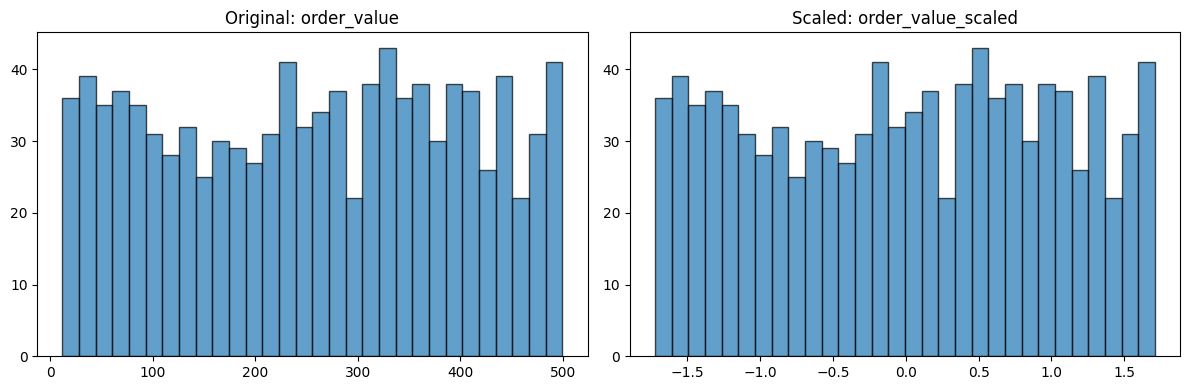

💾 Đã lưu scaler tại outputs/models/scaler.pkl


In [14]:
print("\n" + "=" * 80)
print("🔍 CHUẨN HÓA DỮ LIỆU (SCALING)")
print("=" * 80)

# Xác định các numerical columns để scale (loại trừ binary và target)
cols_to_scale = []
for col in existing_num_cols:
    if col in df_encoded.columns and col != target and col not in id_cols:
        if df_encoded[col].nunique() > 2:  # Không scale binary features
            cols_to_scale.append(col)

print(f"📊 Các cột cần scale ({len(cols_to_scale)} cột):")
if cols_to_scale:
    print(cols_to_scale[:10])  # In 10 cột đầu
else:
    print("   Không có cột nào cần scale")

# Lấy scaling method từ config
clustering_config = config.get('clustering', {}).get('customer_clustering', {})
scaling_method = clustering_config.get('scaling', 'standard')

print(f"\n🛠️ Phương pháp scaling: {scaling_method}")

# Chọn scaler
if scaling_method == 'standard':
    scaler = StandardScaler()
elif scaling_method == 'minmax':
    scaler = MinMaxScaler()
elif scaling_method == 'robust':
    scaler = RobustScaler()
else:
    scaler = StandardScaler()

# Fit và transform
if cols_to_scale:
    df_scaled = df_encoded.copy()
    scaled_values = scaler.fit_transform(df_encoded[cols_to_scale])
    
    # Tạo tên cột mới cho scaled features
    scaled_cols = [f"{col}_scaled" for col in cols_to_scale]
    
    # Gán giá trị scaled vào dataframe
    for i, col in enumerate(scaled_cols):
        df_scaled[col] = scaled_values[:, i]
        if col not in existing_num_cols:
            existing_num_cols.append(col)
    
    print(f"\n✅ Đã scale {len(cols_to_scale)} features")
    
    # So sánh trước và sau scaling
    if cols_to_scale:
        sample_col = cols_to_scale[0]
        print(f"\n📊 So sánh statistics trước và sau scaling cho cột: {sample_col}")
        comparison = pd.DataFrame({
            'Original': df_encoded[sample_col],
            'Scaled': df_scaled[f"{sample_col}_scaled"]
        }).describe()
        display(comparison)
        
        # Vẽ distribution trước và sau scaling
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        axes[0].hist(df_encoded[sample_col], bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_title(f'Original: {sample_col}')
        
        axes[1].hist(df_scaled[f"{sample_col}_scaled"], bins=30, edgecolor='black', alpha=0.7)
        axes[1].set_title(f'Scaled: {sample_col}_scaled')
        
        plt.tight_layout()
        
        # Tạo thư mục nếu chưa có
        os.makedirs('../outputs/figures', exist_ok=True)
        plt.savefig(f'../outputs/figures/feature_scaling_comparison.png', dpi=100, bbox_inches='tight')
        plt.show()
        
        # Lưu scaler để sử dụng sau
        os.makedirs('../outputs/models', exist_ok=True)
        joblib.dump(scaler, '../outputs/models/scaler.pkl')
        print("💾 Đã lưu scaler tại outputs/models/scaler.pkl")
else:
    df_scaled = df_encoded.copy()
    print("⚠️ Không có cột nào cần scale")

In [15]:
print("\n" + "=" * 80)
print("🔍 XỬ LÝ MẤT CÂN BẰNG LỚP")
print("=" * 80)

imbalance_config = config['data']['imbalance']

if target_exists and target in df_scaled.columns:
    # Kiểm tra tỷ lệ mất cân bằng
    class_counts = df_scaled[target].value_counts().sort_index()
    class_ratios = df_scaled[target].value_counts(normalize=True).sort_index()
    
    print(f"📊 Phân phối lớp hiện tại:")
    for cls, count in class_counts.items():
        print(f"   - Class {cls}: {count} ({class_ratios[cls]*100:.2f}%)")
    
    if 0 in class_counts and 1 in class_counts:
        imbalance_ratio = class_counts[0] / class_counts[1]
        print(f"\n📊 Imbalance ratio (0/1): {imbalance_ratio:.2f}")
        
        # Quyết định có cần xử lý imbalance không
        if imbalance_ratio > 5:
            print(f"\n⚠️ Dữ liệu mất cân bằng cao! Cần xử lý imbalance.")
            
            # Chuẩn bị dữ liệu cho sampling
            feature_cols = [col for col in df_scaled.columns if col != target and col not in id_cols and col != date_col]
            feature_cols = [col for col in feature_cols if col in df_scaled.columns and pd.api.types.is_numeric_dtype(df_scaled[col])]
            
            X = df_scaled[feature_cols].fillna(0)
            y = df_scaled[target]
            
            print(f"\n🛠️ Shape trước sampling: X={X.shape}, y={y.shape}")
            
            # Thử các phương pháp sampling
            sampling_methods = {}
            
            # SMOTE
            if imbalance_config['methods'].get('smote', False):
                print("\n🔄 Áp dụng SMOTE...")
                smote = SMOTE(random_state=imbalance_config.get('random_state', 42), 
                              sampling_strategy=imbalance_config.get('sampling_strategy', 'auto'))
                try:
                    X_smote, y_smote = smote.fit_resample(X, y)
                    sampling_methods['SMOTE'] = (X_smote, y_smote)
                    print(f"   ✅ SMOTE thành công: X={X_smote.shape}, y={y_smote.shape}")
                    print(f"   📊 Phân phối sau SMOTE: {pd.Series(y_smote).value_counts().to_dict()}")
                except Exception as e:
                    print(f"   ❌ SMOTE thất bại: {e}")
            
            # Random Oversampling
            if imbalance_config['methods'].get('random_oversampling', False):
                print("\n🔄 Áp dụng Random Oversampling...")
                ros = RandomOverSampler(random_state=imbalance_config.get('random_state', 42), 
                                       sampling_strategy=imbalance_config.get('sampling_strategy', 'auto'))
                try:
                    X_ros, y_ros = ros.fit_resample(X, y)
                    sampling_methods['RandomOver'] = (X_ros, y_ros)
                    print(f"   ✅ Random Oversampling thành công: X={X_ros.shape}, y={y_ros.shape}")
                    print(f"   📊 Phân phối sau RandomOver: {pd.Series(y_ros).value_counts().to_dict()}")
                except Exception as e:
                    print(f"   ❌ Random Oversampling thất bại: {e}")
            
            # Random Undersampling
            if imbalance_config['methods'].get('random_undersampling', False):
                print("\n🔄 Áp dụng Random Undersampling...")
                rus = RandomUnderSampler(random_state=imbalance_config.get('random_state', 42), 
                                        sampling_strategy=imbalance_config.get('sampling_strategy', 'auto'))
                try:
                    X_rus, y_rus = rus.fit_resample(X, y)
                    sampling_methods['RandomUnder'] = (X_rus, y_rus)
                    print(f"   ✅ Random Undersampling thành công: X={X_rus.shape}, y={y_rus.shape}")
                    print(f"   📊 Phân phối sau RandomUnder: {pd.Series(y_rus).value_counts().to_dict()}")
                except Exception as e:
                    print(f"   ❌ Random Undersampling thất bại: {e}")
            
            # Lưu lại để sử dụng sau
            if sampling_methods:
                # Chọn phương pháp tốt nhất (SMOTE nếu thành công)
                if 'SMOTE' in sampling_methods:
                    X_balanced, y_balanced = sampling_methods['SMOTE']
                    method_used = 'SMOTE'
                else:
                    # Chọn phương pháp đầu tiên
                    method_used, (X_balanced, y_balanced) = next(iter(sampling_methods.items()))
                
                # Tạo dataframe balanced
                df_balanced = pd.DataFrame(X_balanced, columns=feature_cols)
                df_balanced[target] = y_balanced.values
                
                print(f"\n✅ Đã tạo dữ liệu cân bằng với phương pháp: {method_used}")
                print(f"📊 Kích thước dữ liệu cân bằng: {df_balanced.shape}")
                
                # Lưu dữ liệu cân bằng
                df_scaled = df_balanced
        else:
            print(f"\n✅ Dữ liệu tương đối cân bằng, không cần xử lý imbalance.")
    else:
        print(f"\n⚠️ Target không phải binary, bỏ qua xử lý imbalance")
else:
    print(f"⚠️ Không tìm thấy target column để xử lý imbalance")


🔍 XỬ LÝ MẤT CÂN BẰNG LỚP
📊 Phân phối lớp hiện tại:
   - Class 0: 913 (91.30%)
   - Class 1: 87 (8.70%)

📊 Imbalance ratio (0/1): 10.49

⚠️ Dữ liệu mất cân bằng cao! Cần xử lý imbalance.

🛠️ Shape trước sampling: X=(1000, 76), y=(1000,)

🔄 Áp dụng SMOTE...
   ✅ SMOTE thành công: X=(1826, 76), y=(1826,)
   📊 Phân phối sau SMOTE: {0: 913, 1: 913}

✅ Đã tạo dữ liệu cân bằng với phương pháp: SMOTE
📊 Kích thước dữ liệu cân bằng: (1826, 77)


In [16]:
print("\n" + "=" * 80)
print("🔍 TẠO TRAIN/TEST SPLIT")
print("=" * 80)

split_config = config['classification']['split']
test_size = split_config['test_size']
random_state = split_config['random_state']
stratify = split_config.get('stratify', True)

print(f"🛠️ Cấu hình split:")
print(f"   - Test size: {test_size}")
print(f"   - Random state: {random_state}")
print(f"   - Stratify: {stratify}")

if target_exists and target in df_scaled.columns:
    # Xác định features và target
    feature_cols = [col for col in df_scaled.columns 
                    if col != target 
                    and col not in id_cols 
                    and col != date_col
                    and not col.endswith('_name')
                    and pd.api.types.is_numeric_dtype(df_scaled[col])]
    
    X = df_scaled[feature_cols].fillna(0)
    y = df_scaled[target]
    
    print(f"\n📊 Features shape: {X.shape}")
    print(f"📊 Target shape: {y.shape}")
    print(f"\n📌 Danh sách features ({len(X.columns)} features):")
    print(list(X.columns)[:20])  # In 20 features đầu
    if len(X.columns) > 20:
        print(f"   ... và {len(X.columns) - 20} features khác")
    
    # Train/test split
    try:
        if stratify:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=random_state, stratify=y
            )
            print(f"\n✅ Stratified split thành công")
        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=random_state
            )
            print(f"\n✅ Random split thành công")
        
        print(f"\n📊 Kích thước các tập:")
        print(f"   - Train: X_train={X_train.shape}, y_train={y_train.shape}")
        print(f"   - Test: X_test={X_test.shape}, y_test={y_test.shape}")
        
        # Kiểm tra phân phối lớp trong train/test
        print(f"\n📊 Phân phối lớp trong train:")
        train_dist = y_train.value_counts(normalize=True).sort_index()
        for cls, pct in train_dist.items():
            print(f"   - Class {cls}: {pct*100:.2f}%")
        
        print(f"\n📊 Phân phối lớp trong test:")
        test_dist = y_test.value_counts(normalize=True).sort_index()
        for cls, pct in test_dist.items():
            print(f"   - Class {cls}: {pct*100:.2f}%")
        
        # Lưu train/test sets
        train_data = X_train.copy()
        train_data[target] = y_train.values
        
        test_data = X_test.copy()
        test_data[target] = y_test.values
        
        # Lưu thành file
        processed_path = config['paths']['processed_data']
        os.makedirs(processed_path, exist_ok=True)
        
        train_data.to_parquet(f'{processed_path}/train_data.parquet', index=False)
        test_data.to_parquet(f'{processed_path}/test_data.parquet', index=False)
        
        print(f"\n💾 Đã lưu train/test data tại: {processed_path}")
        
        # Lưu feature list
        with open(f'{processed_path}/feature_list.json', 'w', encoding='utf-8') as f:
            json.dump({
                'features': list(X.columns),
                'target': target,
                'n_features': len(X.columns),
                'n_train': len(X_train),
                'n_test': len(X_test)
            }, f, indent=2)
        
        print(f"📋 Đã lưu feature list")
    except Exception as e:
        print(f"❌ Lỗi khi tạo train/test split: {e}")
else:
    print(f"⚠️ Không tìm thấy target, bỏ qua train/test split")


🔍 TẠO TRAIN/TEST SPLIT
🛠️ Cấu hình split:
   - Test size: 0.2
   - Random state: 42
   - Stratify: True

📊 Features shape: (1826, 76)
📊 Target shape: (1826,)

📌 Danh sách features (76 features):
['order_value', 'quantity', 'discount_amount', 'shipping_cost', 'recency_days', 'frequency', 'monetary_total', 'avg_order_value', 'customer_return_rate', 'total_returns', 'product_return_rate', 'category_return_rate', 'customer_hist_return_rate', 'value_per_item', 'discount_rate', 'shipping_ratio', 'season_encoded', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3']
   ... và 56 features khác

✅ Stratified split thành công

📊 Kích thước các tập:
   - Train: X_train=(1460, 76), y_train=(1460,)
   - Test: X_test=(366, 76), y_test=(366,)

📊 Phân phối lớp trong train:
   - Class 0: 50.00%
   - Class 1: 50.00%

📊 Phân phối lớp trong test:
   - Class 0: 50.00%
   - Class 1: 50.00%

💾 Đã lưu train/test data tại: data/processed/
📋 Đã lưu feature list


In [17]:
print("\n" + "=" * 80)
print("💾 TỔNG HỢP VÀ LƯU DỮ LIỆU")
print("=" * 80)

# Lưu dữ liệu đã xử lý đầy đủ
processed_path = config['paths']['processed_data']
features_mining_path = config['paths']['features_mining']
features_modeling_path = config['paths']['features_modeling']

# Tạo thư mục nếu chưa có
os.makedirs(processed_path, exist_ok=True)
os.makedirs('../outputs/tables', exist_ok=True)

# Dữ liệu cho mining (giữ cả categorical gốc)
mining_cols = [col for col in df_processed.columns if col not in id_cols]
df_mining = df_processed[mining_cols].copy()

try:
    df_mining.to_parquet(features_mining_path, index=False)
    print(f"✅ Đã lưu dữ liệu cho mining tại: {features_mining_path}")
    print(f"   - Shape: {df_mining.shape}")
except Exception as e:
    print(f"⚠️ Không thể lưu parquet: {e}")
    # Thử lưu CSV
    csv_path = features_mining_path.replace('.parquet', '.csv')
    df_mining.to_csv(csv_path, index=False, encoding='utf-8')
    print(f"✅ Đã lưu dữ liệu dạng CSV tại: {csv_path}")

# Dữ liệu cho modeling (đã scale và xử lý)
if 'df_scaled' in locals():
    modeling_cols = [col for col in df_scaled.columns if col not in id_cols and col != date_col]
    df_modeling = df_scaled[modeling_cols].copy()
    
    try:
        df_modeling.to_parquet(features_modeling_path, index=False)
        print(f"✅ Đã lưu dữ liệu cho modeling tại: {features_modeling_path}")
        print(f"   - Shape: {df_modeling.shape}")
    except Exception as e:
        print(f"⚠️ Không thể lưu parquet: {e}")
        csv_path = features_modeling_path.replace('.parquet', '.csv')
        df_modeling.to_csv(csv_path, index=False, encoding='utf-8')
        print(f"✅ Đã lưu dữ liệu dạng CSV tại: {csv_path}")

# Tổng hợp quá trình preprocessing
new_features = [col for col in df_processed.columns if col not in df.columns]

preprocessing_summary = {
    'original_shape': list(df.shape),
    'after_missing_handling': list(df_processed.shape),
    'after_outlier_treatment': list(df_processed.shape),
    'after_duplicate_removal': list(df_processed.shape),
    'after_feature_engineering': list(df_processed.shape),
    'after_encoding': list(df_encoded.shape) if 'df_encoded' in locals() else None,
    'after_scaling': list(df_scaled.shape) if 'df_scaled' in locals() else None,
    'after_imbalance': list(df_scaled.shape) if 'df_scaled' in locals() else None,
    'n_features_final': len(df_scaled.columns) if 'df_scaled' in locals() else None,
    'categorical_columns': existing_cat_cols,
    'numerical_columns': existing_num_cols,
    'new_features_created': new_features[:50]  # Chỉ lưu 50 features đầu
}

# Lưu summary
with open('../outputs/tables/preprocessing_summary.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_summary, f, indent=2, default=str, ensure_ascii=False)

print("\n📊 Tổng hợp quá trình preprocessing:")
for key, value in preprocessing_summary.items():
    if not isinstance(value, list) or key not in ['categorical_columns', 'numerical_columns', 'new_features_created']:
        print(f"   - {key}: {value}")

print("\n📊 Các features mới được tạo:")
for feat in new_features[:20]:  # Chỉ in 20 features đầu
    print(f"   - {feat}")
if len(new_features) > 20:
    print(f"   ... và {len(new_features) - 20} features khác")


💾 TỔNG HỢP VÀ LƯU DỮ LIỆU
⚠️ Không thể lưu parquet: ("Expected bytes, got a 'int' object", 'Conversion failed for column promotion_code with type object')
✅ Đã lưu dữ liệu dạng CSV tại: data/processed/features_for_mining.csv
✅ Đã lưu dữ liệu cho modeling tại: data/processed/features_for_modeling.parquet
   - Shape: (1826, 77)

📊 Tổng hợp quá trình preprocessing:
   - original_shape: [1000, 13]
   - after_missing_handling: [1000, 32]
   - after_outlier_treatment: [1000, 32]
   - after_duplicate_removal: [1000, 32]
   - after_feature_engineering: [1000, 32]
   - after_encoding: [1000, 69]
   - after_scaling: [1826, 77]
   - after_imbalance: [1826, 77]
   - n_features_final: 77

📊 Các features mới được tạo:
   - day_of_week
   - day_name
   - month
   - quarter
   - is_weekend
   - hour_of_day
   - week_of_year
   - season
   - recency_days
   - frequency
   - monetary_total
   - avg_order_value
   - customer_return_rate
   - total_returns
   - product_return_rate
   - category_return_ra


✅ KIỂM TRA CHẤT LƯỢNG DỮ LIỆU SAU XỬ LÝ
📊 Missing values: 0
   ✅ Không còn missing values
📊 Infinite values: 0
   ✅ Không còn infinite values

📊 Data types sau xử lý:
   - bool: 43 columns
   - float64: 28 columns
   - int64: 5 columns
   - int32: 1 columns

📊 Phân phối target sau xử lý:
   - Class 0: 50.00%
   - Class 1: 50.00%


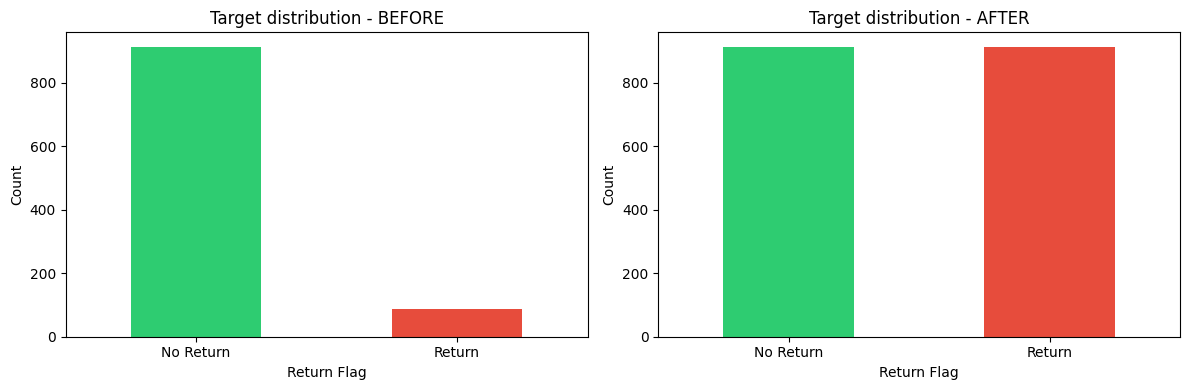


🎉 HOÀN THÀNH TIỀN XỬ LÝ VÀ FEATURE ENGINEERING

✅ Sẵn sàng chuyển sang notebook 03_mining_clustering.ipynb


In [18]:
print("\n" + "=" * 80)
print("✅ KIỂM TRA CHẤT LƯỢNG DỮ LIỆU SAU XỬ LÝ")
print("=" * 80)

if 'df_scaled' in locals():
    # Kiểm tra missing values
    missing_final = df_scaled.isnull().sum().sum()
    print(f"📊 Missing values: {missing_final}")
    if missing_final == 0:
        print("   ✅ Không còn missing values")
    else:
        print(f"   ⚠️ Còn {missing_final} missing values cần xử lý")
        # Xử lý nốt
        df_scaled = df_scaled.fillna(0)
        print("   ✅ Đã fill các missing còn lại bằng 0")

    # Kiểm tra infinite values
    inf_final = np.isinf(df_scaled.select_dtypes(include=[np.number])).sum().sum()
    print(f"📊 Infinite values: {inf_final}")
    if inf_final == 0:
        print("   ✅ Không còn infinite values")
    else:
        print(f"   ⚠️ Còn {inf_final} infinite values")
        # Thay thế infinite bằng 0
        df_scaled = df_scaled.replace([np.inf, -np.inf], 0)
        print("   ✅ Đã thay thế infinite values bằng 0")

    # Kiểm tra data types
    print(f"\n📊 Data types sau xử lý:")
    dtype_summary = df_scaled.dtypes.value_counts()
    for dtype, count in dtype_summary.items():
        print(f"   - {dtype}: {count} columns")

    # Kiểm tra phân phối của target (nếu có)
    if target_exists and target in df_scaled.columns:
        print(f"\n📊 Phân phối target sau xử lý:")
        target_dist = df_scaled[target].value_counts(normalize=True).sort_index()
        for cls, pct in target_dist.items():
            print(f"   - Class {cls}: {pct*100:.2f}%")
        
        # Vẽ biểu đồ phân phối target
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Trước xử lý
        if target in df.columns:
            df[target].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
            axes[0].set_title('Target distribution - BEFORE')
            axes[0].set_xlabel('Return Flag')
            axes[0].set_ylabel('Count')
            axes[0].set_xticklabels(['No Return', 'Return'], rotation=0)
        
        # Sau xử lý
        if target in df_scaled.columns:
            df_scaled[target].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
            axes[1].set_title('Target distribution - AFTER')
            axes[1].set_xlabel('Return Flag')
            axes[1].set_ylabel('Count')
            axes[1].set_xticklabels(['No Return', 'Return'], rotation=0)
        
        plt.tight_layout()
        
        # Tạo thư mục nếu chưa có
        os.makedirs('../outputs/figures', exist_ok=True)
        plt.savefig('../outputs/figures/preprocess_target_comparison.png', dpi=100, bbox_inches='tight')
        plt.show()
else:
    print("❌ Không có dữ liệu để kiểm tra")

print("\n" + "=" * 80)
print("🎉 HOÀN THÀNH TIỀN XỬ LÝ VÀ FEATURE ENGINEERING")
print("=" * 80)
print("\n✅ Sẵn sàng chuyển sang notebook 03_mining_clustering.ipynb")